In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')

In [2]:
data = pd.read_csv('data/all_three_comparison.csv', index_col=0)

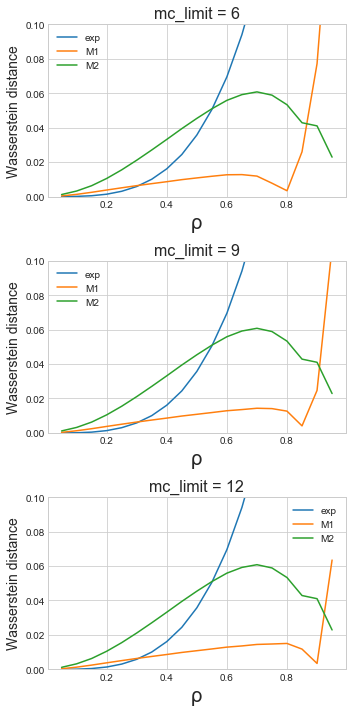

In [11]:
fig, axarr = plt.subplots(3, figsize=(5, 10))
for i, R in enumerate([6, 9, 12]):
    axarr[i].plot(data[data['mc_limit'] == R]['rhos'], data[data['mc_limit'] == R]['w_exp'], label='exp')
    axarr[i].plot(data[data['mc_limit'] == R]['rhos'], data[data['mc_limit'] == R]['w_M1'], label='M1')
    axarr[i].plot(data[data['mc_limit'] == R]['rhos'], data[data['mc_limit'] == R]['w_M2'], label='M2')
    axarr[i].set_ylim(0, 0.1)
    axarr[i].legend()
    axarr[i].set_title(f'mc_limit = {R}', fontsize=16)
    axarr[i].set_ylabel('Wasserstein distance', fontsize=14)
    axarr[i].set_xlabel('ρ', fontsize=20)
plt.tight_layout()
plt.show()

# Therefore:
  + Exponential distribution the most accurate up to say $\rho < 0.3$
  + Method 1 the most accurate $\rho > 0.3$ if we use a large mc_limit; but this compromises runtime
  + Method 2 least accurate but quicker, probably the most practical to use above $\rho > 0.85$ (we should probably decide what kind of maximum runtime we can consider as 'practical', and we can get a better idea pf the best mc_limit top use)
  + For very large $\rho$, say $\rho > 0.9$, Method 1 struggles. This might be due to not a big enough mc_limit, it might be due to numerical error (Method 1 has some matrix calculations that Method 2 does not).

Even though this is based on a specific $\lambda$, I believe this would only affect the runtime of the simulation, not the other methods.